### Imports / Load

In [1]:
import earthkit.data as ekd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import xarray as xr
import ee
import numpy as np

import sys
sys.path.append("..")

# ee.Authenticate()  # only needed once
ee.Initialize(project="climate-pollinator-explorer")

region = ee.Geometry.Rectangle([-4.5, 50.0, -2.5, 51.5])
pilot_bbox = box(-4.5, 50.0, -2.5, 51.5)
lon_min, lat_min, lon_max, lat_max = -4.5, 50.0, -2.5, 51.5


### Temperature

In [3]:
from src.data.era5 import load_era5

area = [lat_max, lon_min, lat_min, lon_max]
ds = load_era5(year=2021, month=7, days=['01', '02', '03'], area=area)
print(ds)


2026-07-15 19:23:15,411 INFO Request ID is 2dabdb6c-fcf7-4ae9-b308-5fdd2060a2cb
2026-07-15 19:23:15,501 INFO status has been updated to accepted
2026-07-15 19:23:36,874 INFO status has been updated to successful


<xarray.Dataset> Size: 2kB
Dimensions:     (valid_time: 3, latitude: 7, longitude: 9)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 24B 2021-07-01T12:00:00 ... 2021-...
    expver      (valid_time) <U4 48B ...
  * latitude    (latitude) float64 56B 51.5 51.25 51.0 50.75 50.5 50.25 50.0
  * longitude   (longitude) float64 72B -4.5 -4.25 -4.0 ... -3.0 -2.75 -2.5
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 756B 288.0 ... 288.5
    t2m_C       (valid_time, latitude, longitude) float32 756B 14.86 ... 15.33
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-14T09:27 GRIB to CDM+CF via cfgrib-0.9.1...


### NDVI

In [31]:
ndvi_collection = (
    ee.ImageCollection("MODIS/061/MOD13Q1")
    .filterDate("2021-07-01", "2021-07-31")
    .filterBounds(region)
    .select("NDVI")
)

ndvi_image = (
    ndvi_collection.mean()
    .clip(region)
    .reproject(crs="EPSG:4326", scale=500)
)

sample = ndvi_image.sampleRectangle(region=region, defaultValue=0)
ndvi_array = sample.get("NDVI").getInfo()
ndvi_np = np.array(ndvi_array) / 10000

n_lat, n_lon = ndvi_np.shape 
lats = np.linspace(lat_max, lat_min, n_lat)  
lons = np.linspace(lon_min, lon_max, n_lon)  

ndvi_da = xr.DataArray(
    ndvi_np, dims=["lat", "lon"], coords={"lat": lats, "lon": lons}, name="ndvi"
)

ndvi_regridded = ndvi_da.interp(lat=ds.latitude, lon=ds.longitude, method="linear")
print(ndvi_regridded.shape)


(7, 9)


### SPEI

In [32]:
spei = xr.open_dataset("../data_cache/spei/spei03.nc")
spei_uk_buffered = spei.sel(lat=slice(49.0, 52.5), lon=slice(-5.5, -1.5))
spei_uk_buffered = spei_uk_buffered.where(spei_uk_buffered["spei"] < 1e29)
spei_uk_buffered = spei_uk_buffered.ffill(dim="lon").bfill(dim="lon").ffill(dim="lat").bfill(dim="lat")
spei_pilot = spei_uk_buffered.sel(time="2021-07-16", method="nearest")
spei_regridded = spei_pilot.interp(lat=ds.latitude, lon=ds.longitude, method="nearest")

### BLines

In [33]:
blines = gpd.read_file("../data_cache/blines/blines_uk.gpkg")
blines_4326 = blines.to_crs(epsg=4326)

pilot_bbox = box(-4.5, 50.0, -2.5, 51.5)
blines_clip = blines_4326.clip(pilot_bbox)

print(blines.geometry.geom_type)
print(blines.geometry.iloc[0].geoms.__len__() if hasattr(blines.geometry.iloc[0], 'geoms') else "not multi")

blines_exploded = blines_4326.explode(index_parts=False).reset_index(drop=True)
print(blines_exploded.shape) 

0    MultiPolygon
dtype: str
198
(198, 4)


### Land Cover

In [34]:
landcover = ee.ImageCollection("ESA/WorldCover/v200").first().clip(region)

sample = landcover.reproject(crs="EPSG:4326", scale=500).sampleRectangle(region=region, defaultValue=0)
lc_array = sample.get("Map").getInfo()
lc_np = np.array(lc_array)

lc_da = xr.DataArray(
    lc_np, dims=["lat", "lon"], coords={"lat": lats, "lon": lons}, name="landcover"
)

lc_regridded = lc_da.interp(lat=ds.latitude, lon=ds.longitude, method="nearest")


print(lc_regridded.shape) 
print(np.unique(lc_regridded))

(7, 9)
[ 0. 10. 30. 40. 50. 80.]


### Flowering Season

In [35]:
FLOWERING_SEASON = {
    1: 0.0,   # Jan
    2: 0.1,   # Feb
    3: 0.4,   # Mar
    4: 0.7,   # Apr
    5: 1.0,   # May
    6: 1.0,   # Jun
    7: 1.0,   # Jul
    8: 0.8,   # Aug
    9: 0.5,   # Sep
    10: 0.2,  # Oct
    11: 0.0,  # Nov
    12: 0.0,  # Dec
}

def flowering_score(month: int) -> float:
    return FLOWERING_SEASON[month]

print(flowering_score(7))

1.0


### Plots

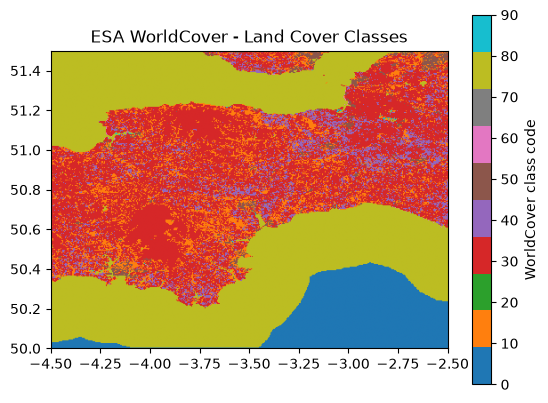

In [36]:
plt.imshow(lc_np, cmap="tab10", extent=[-4.5, -2.5, 50.0, 51.5])
plt.colorbar(label="WorldCover class code")
plt.title("ESA WorldCover - Land Cover Classes")
plt.show()

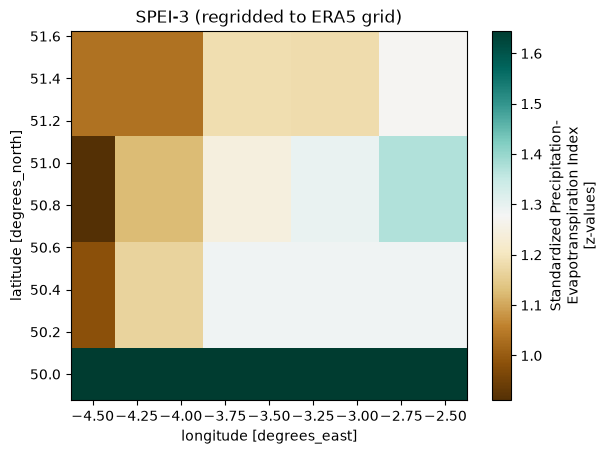

In [37]:
spei_regridded["spei"].plot(cmap="BrBG")
plt.title("SPEI-3 (regridded to ERA5 grid)")
plt.show()

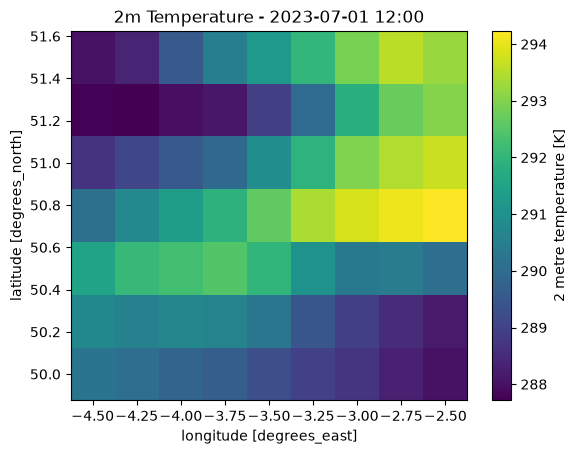

In [38]:
#Convert to celsius
ds["t2m_C"] = ds["t2m"] - 273.15


ds["t2m"].isel(valid_time=0).plot()
plt.title("2m Temperature - 2023-07-01 12:00")
plt.show()

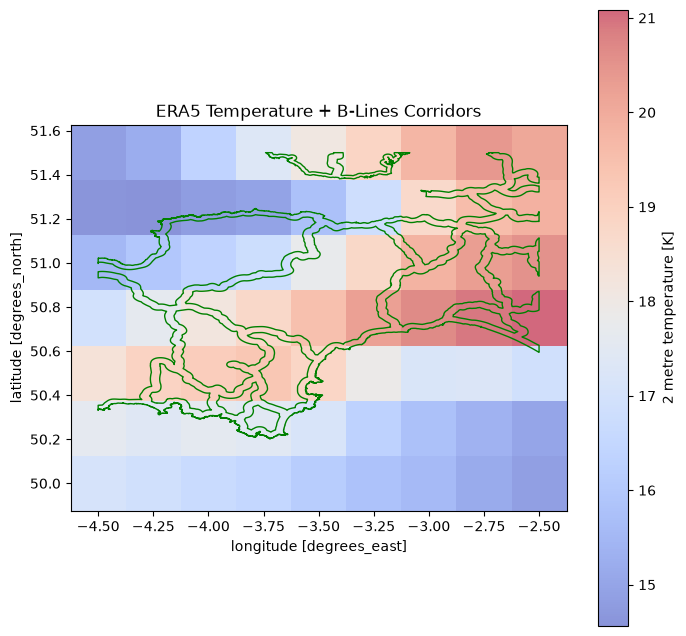

In [39]:
fig, ax = plt.subplots(figsize=(8,8))

ds["t2m_C"].isel(valid_time=0).plot(
    ax=ax,
    cmap="coolwarm",
    alpha=0.6
)

blines_clip.plot(
    ax=ax,
    color="none",
    edgecolor="green",
    linewidth=1
)

ax.set_aspect("equal")      # <-- here

plt.title("ERA5 Temperature + B-Lines Corridors")
plt.show()

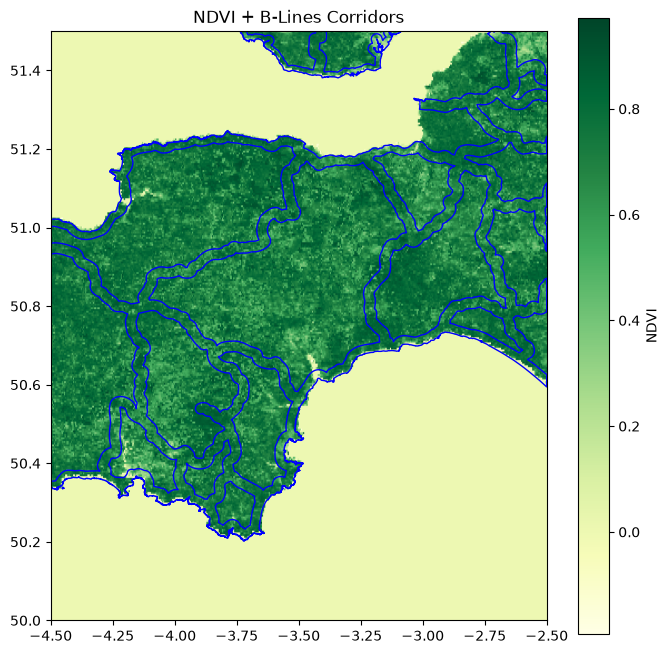

In [40]:
fig, ax = plt.subplots(figsize=(8,8))
plt.imshow(ndvi_np, cmap="YlGn", extent=[-4.5, -2.5, 50.0, 51.5])
blines_clip.plot(ax=ax, color="none", edgecolor="blue", linewidth=1)
plt.title("NDVI + B-Lines Corridors")
plt.colorbar(label="NDVI")
plt.show()

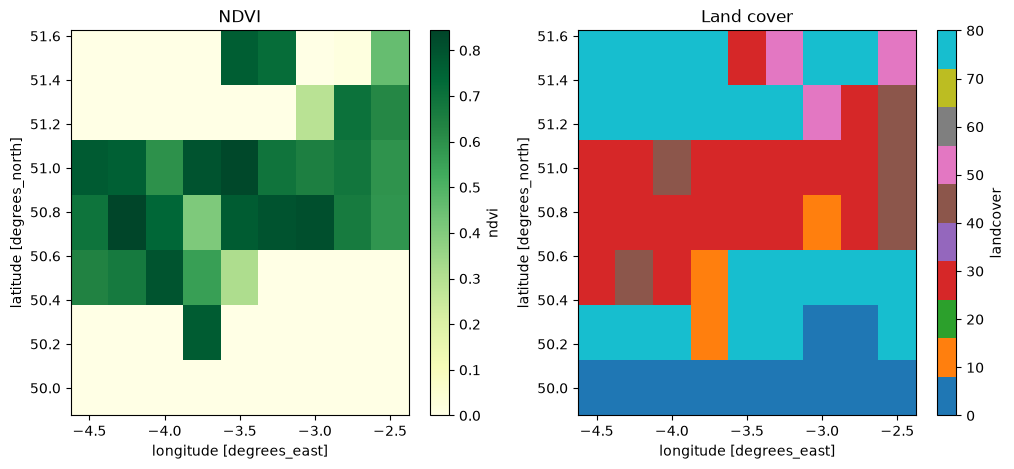

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
ndvi_regridded.plot(ax=axes[0], cmap="YlGn")
axes[0].set_title("NDVI")
lc_regridded.plot(ax=axes[1], cmap="tab10")
axes[1].set_title("Land cover")
plt.show()

### Save Loaded Data

In [42]:
import os

print("==== DIMENSIONS ===")

era5_t2m = ds["t2m_C"].isel(valid_time=0)

print(era5_t2m.dims)
print(spei_regridded["spei"].dims)
print(ndvi_regridded.dims)
print(lc_regridded.dims)

print("===== COORDINATES ====")

era5_t2m = era5_t2m.drop_vars(["number", "valid_time", "expver"], errors="ignore")
spei_regridded = spei_regridded.drop_vars(["lat", "lon", "time", "number"], errors="ignore")
ndvi_regridded = ndvi_regridded.drop_vars(["lat", "lon", "number"], errors="ignore")
lc_regridded = lc_regridded.drop_vars(["lat", "lon", "number"], errors="ignore")

print(era5_t2m.coords)
print(spei_regridded["spei"].coords)
print(ndvi_regridded.coords)
print(lc_regridded.coords)

finalds = xr.merge([era5_t2m, spei_regridded, ndvi_regridded, lc_regridded])
finalds = finalds.rename({"t2m_C": "temperature"})

os.makedirs("../data_cache/loadedData", exist_ok=True)

finalds.to_netcdf(path="../data_cache/loadedData/pilot_aligned.nc")
blines_exploded.to_file("../data_cache/loadedData/pilot_blines_exploded.gpkg")

==== DIMENSIONS ===
('latitude', 'longitude')
('latitude', 'longitude')
('latitude', 'longitude')
('latitude', 'longitude')
===== COORDINATES ====
Coordinates:
  * latitude   (latitude) float64 56B 51.5 51.25 51.0 50.75 50.5 50.25 50.0
  * longitude  (longitude) float64 72B -4.5 -4.25 -4.0 -3.75 ... -3.0 -2.75 -2.5
Coordinates:
  * latitude   (latitude) float64 56B 51.5 51.25 51.0 50.75 50.5 50.25 50.0
  * longitude  (longitude) float64 72B -4.5 -4.25 -4.0 -3.75 ... -3.0 -2.75 -2.5
Coordinates:
  * latitude   (latitude) float64 56B 51.5 51.25 51.0 50.75 50.5 50.25 50.0
  * longitude  (longitude) float64 72B -4.5 -4.25 -4.0 -3.75 ... -3.0 -2.75 -2.5
Coordinates:
  * latitude   (latitude) float64 56B 51.5 51.25 51.0 50.75 50.5 50.25 50.0
  * longitude  (longitude) float64 72B -4.5 -4.25 -4.0 -3.75 ... -3.0 -2.75 -2.5
